In [1]:
import pandas as pd

# exibir todas as colunas
pd.set_option('display.max_columns', None)

url = "https://raw.githubusercontent.com/tmedeirosb/tsi-ad-2025/refs/heads/main/dados/dados_workflow_ivan.csv"
df = pd.read_csv(url)

display(df.head())

,LnguaPortuguesaeLiteraturaI90H,LnguaPortuguesaeLiteraturaI90H_dependencia,LnguaPortuguesaeLiteraturaI90H_freq,MatemticaI120H,MatemticaI120H_dependencia,MatemticaI120H_freq,aluno_exclusivo_rede_publica,descricao,descricao_area_residencial,descricao_companhia_domiciliar,descricao_estado_civil,descricao_historico,descricao_imovel,descricao_mae_escolaridade,descricao_pai_escolaridade,descricao_raca,descricao_responsavel_escolaridade,descricao_responsavel_financeiro,descricao_trabalho,id,idade,pessoa_fisica__sexo,possui_necessidade_especial,qnt_pc,qtd_pessoas_domicilio,sigla,tempo_entre_conclusao_ingresso,qnt_salarios,artificial,classe,conceito,conceito_freq,acompanhamento
0,68.0,0,100.0,66.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Branca,Ensino fundamental incompleto,Mãe,Não informado,457884597605,15,F,False,0,2,LAJ,1,1,0,1,B,A,0
1,73.0,1,100.0,36.0,1,91.0,False,Cancelado,Urbana,Mãe,Solteiro(a),Técnico de Nível Médio em Meio Ambiente,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Parda,Ensino fundamental incompleto,Mãe,Não informado,458436647741,17,M,False,1,2,SPP,2,1,1,0,R,R,0
2,61.0,0,100.0,60.0,0,100.0,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino médio completo,Ensino médio completo,Parda,Ensino médio completo,Mãe,Não informado,464029640533,15,M,True,0,5,CANG,2,2,0,1,B,A,0
3,NaN,-1,NaN,NaN,-1,NaN,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nível Médio em Mecânica,Alugado,Alfabetizado,Não estudou,Parda,Ensino fundamental incompleto,Mãe,Não está trabalhando,556372572373,16,F,False,1,5,MO,3,2,0,1,S,S,0
4,69.0,0,100.0,63.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Preta,Ensino fundamental incompleto,Mãe,Não está trabalhando,457614148801,15,F,False,0,3,PAR,1,1,0,1,R,A,2


In [2]:
df_sel = df[['LnguaPortuguesaeLiteraturaI90H', 'MatemticaI120H', 'descricao_responsavel_escolaridade', 'idade', 'descricao_raca', 'pessoa_fisica__sexo', 'classe']]
df_sel

,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo,classe
0,68.0,66.0,Ensino fundamental incompleto,15,Branca,F,1
1,73.0,36.0,Ensino fundamental incompleto,17,Parda,M,0
2,61.0,60.0,Ensino médio completo,15,Parda,M,1
3,NaN,NaN,Ensino fundamental incompleto,16,Parda,F,1
4,69.0,63.0,Ensino fundamental incompleto,15,Preta,F,1
...,...,...,...,...,...,...,...
8903,29.0,11.0,Ensino fundamental incompleto,15,Amarela,M,0
8904,86.0,71.0,Ensino fundamental incompleto,15,Branca,F,1
8905,61.0,67.0,Ensino fundamental incompleto,15,Parda,F,1
8906,93.0,78.0,Ensino fundamental incompleto,14,Parda,F,1


## Pipeline sklearn com pré-processamento e modelos de classificação

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Separar features (X) e target (y)
X = df_sel.drop('classe', axis=1)
y = df_sel['classe']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nDistribuição da classe:\n{y.value_counts()}")

# Identificar colunas numéricas e categóricas a partir de X
colunas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
colunas_categoricas = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nColunas numéricas:", colunas_numericas)
print("Colunas categóricas:", colunas_categoricas)

Shape de X: (8908, 6)
Shape de y: (8908,)

Distribuição da classe:
classe
1    8352
0     556
Name: count, dtype: int64

Colunas numéricas: ['LnguaPortuguesaeLiteraturaI90H', 'MatemticaI120H', 'idade']
Colunas categóricas: ['descricao_responsavel_escolaridade', 'descricao_raca', 'pessoa_fisica__sexo']


In [5]:
# Inverter os valores da classe (0 -> 1, 1 -> 0)
y = 1 - y

print("Classe invertida!")
print(f"Distribuição da classe (invertida):\n{y.value_counts()}")

Classe invertida!
Distribuição da classe (invertida):
classe
0    8352
1     556
Name: count, dtype: int64


In [6]:
# Divisão dos dados com stratify (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"\nDistribuição da classe no conjunto de treino:\n{y_train.value_counts()}")
print(f"\nDistribuição da classe no conjunto de teste:\n{y_test.value_counts()}")

Shape X_train: (7126, 6)
Shape X_test: (1782, 6)

Distribuição da classe no conjunto de treino:
classe
0    6681
1     445
Name: count, dtype: int64

Distribuição da classe no conjunto de teste:
classe
0    1671
1     111
Name: count, dtype: int64


### Criação do Pipeline com pré-processamento

In [7]:
# Definir os transformadores para dados numéricos e categóricos
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', MinMaxScaler())
        ]), colunas_numericas),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False))
        ]), colunas_categoricas)
    ]
)

print("Pipeline de pré-processamento criado com sucesso!")

Pipeline de pré-processamento criado com sucesso!


### Modelo 1: Regressão Logística

In [8]:
# Pipeline com Regressão Logística
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Treinar o modelo
pipeline_lr.fit(X_train, y_train)

# Fazer predições
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

print("Regressão Logística treinada com sucesso!")
print(f"\nAcurácia no conjunto de teste: {pipeline_lr.score(X_test, y_test):.4f}")

Regressão Logística treinada com sucesso!

Acurácia no conjunto de teste: 0.9439


### Modelo 2: Árvore de Decisão

In [9]:
# Pipeline com Árvore de Decisão
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Treinar o modelo
pipeline_dt.fit(X_train, y_train)

# Fazer predições
y_pred_dt = pipeline_dt.predict(X_test)
y_pred_proba_dt = pipeline_dt.predict_proba(X_test)[:, 1]

print("Árvore de Decisão treinada com sucesso!")
print(f"\nAcurácia no conjunto de teste: {pipeline_dt.score(X_test, y_test):.4f}")

Árvore de Decisão treinada com sucesso!

Acurácia no conjunto de teste: 0.9248


### Funções para cálculo de G-Mean

In [10]:
def calcular_gmean(y_true, y_pred):
    """
    Calcula G-Mean: raiz quadrada do produto de Sensitivity (Recall) e Specificity
    G-Mean = sqrt(Sensitivity * Specificity)
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Sensitivity (TPR)
    sensitivity = tp / (tp + fn)
    
    # Specificity (TNR)
    specificity = tn / (tn + fp)
    
    # G-Mean
    gmean = np.sqrt(sensitivity * specificity)
    
    return gmean, sensitivity, specificity

print("Função G-Mean definida!")

Função G-Mean definida!


### Avaliação: Regressão Logística

In [11]:
print("="*60)
print("REGRESSÃO LOGÍSTICA - MÉTRICAS DE AVALIAÇÃO")
print("="*60)

# Matriz de Confusão
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nMatriz de Confusão:")
print(cm_lr)

# Cálculo das métricas
recall_lr = recall_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
gmean_lr, sens_lr, spec_lr = calcular_gmean(y_test, y_pred_lr)

print(f"\nRecall: {recall_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"AUC-ROC: {auc_lr:.4f}")
print(f"G-Mean: {gmean_lr:.4f}")
print(f"  - Sensitivity (TPR): {sens_lr:.4f}")
print(f"  - Specificity (TNR): {spec_lr:.4f}")

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_lr))

REGRESSÃO LOGÍSTICA - MÉTRICAS DE AVALIAÇÃO

Matriz de Confusão:
[[1650   21]
 [  79   32]]

Recall: 0.2883
Precision: 0.6038
AUC-ROC: 0.8754
G-Mean: 0.5335
  - Sensitivity (TPR): 0.2883
  - Specificity (TNR): 0.9874

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1671
           1       0.60      0.29      0.39       111

    accuracy                           0.94      1782
   macro avg       0.78      0.64      0.68      1782
weighted avg       0.93      0.94      0.93      1782



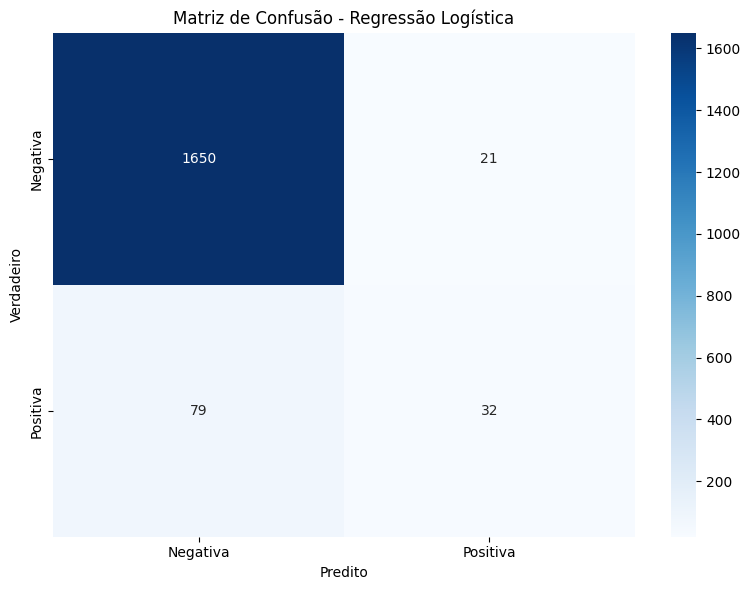

In [12]:
# Visualizar Matriz de Confusão para Regressão Logística
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Negativa', 'Positiva'],
            yticklabels=['Negativa', 'Positiva'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

### Avaliação: Árvore de Decisão

In [13]:
print("="*60)
print("ÁRVORE DE DECISÃO - MÉTRICAS DE AVALIAÇÃO")
print("="*60)

# Matriz de Confusão
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nMatriz de Confusão:")
print(cm_dt)

# Cálculo das métricas
recall_dt = recall_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
gmean_dt, sens_dt, spec_dt = calcular_gmean(y_test, y_pred_dt)

print(f"\nRecall: {recall_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"AUC-ROC: {auc_dt:.4f}")
print(f"G-Mean: {gmean_dt:.4f}")
print(f"  - Sensitivity (TPR): {sens_dt:.4f}")
print(f"  - Specificity (TNR): {spec_dt:.4f}")

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_dt))

ÁRVORE DE DECISÃO - MÉTRICAS DE AVALIAÇÃO

Matriz de Confusão:
[[1597   74]
 [  60   51]]

Recall: 0.4595
Precision: 0.4080
AUC-ROC: 0.7162
G-Mean: 0.6627
  - Sensitivity (TPR): 0.4595
  - Specificity (TNR): 0.9557

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1671
           1       0.41      0.46      0.43       111

    accuracy                           0.92      1782
   macro avg       0.69      0.71      0.70      1782
weighted avg       0.93      0.92      0.93      1782



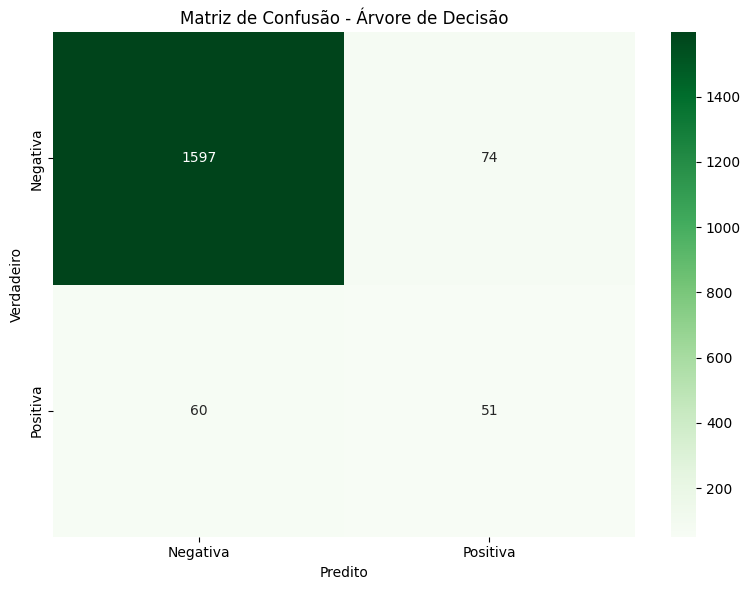

In [14]:
# Visualizar Matriz de Confusão para Árvore de Decisão
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Negativa', 'Positiva'],
            yticklabels=['Negativa', 'Positiva'])
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

### Comparação: Curvas ROC e Resumo de Métricas

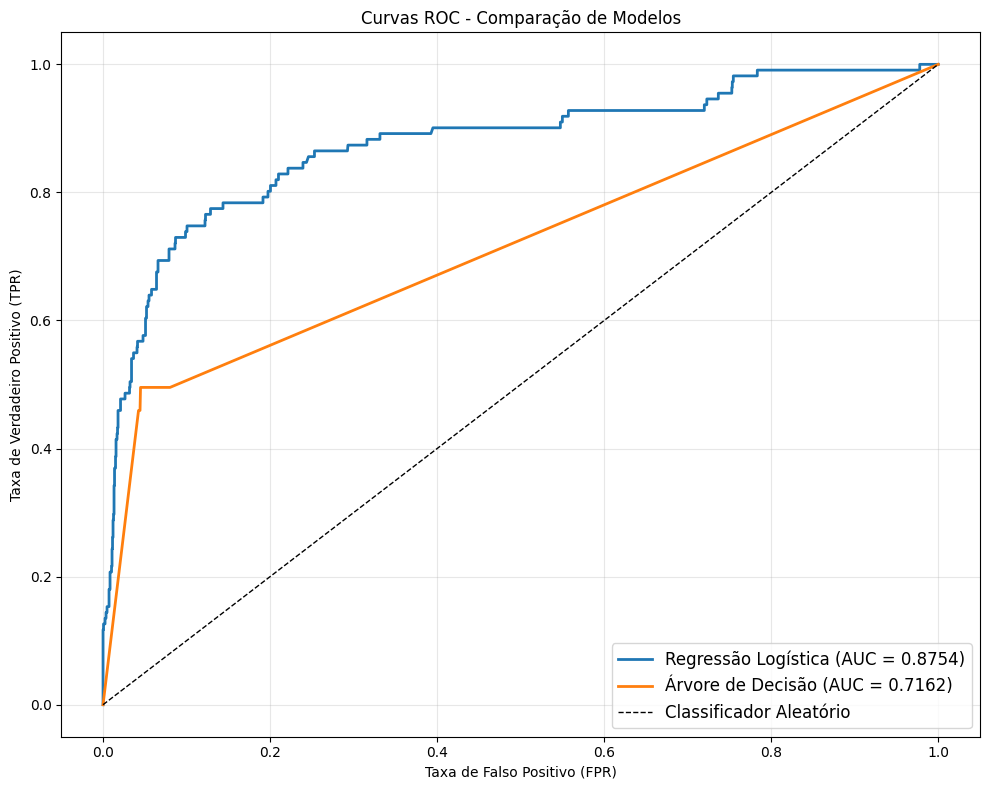

In [15]:
# Plotar curvas ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Árvore de Decisão (AUC = {auc_dt:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório', linewidth=1)
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curvas ROC - Comparação de Modelos')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Resumo comparativo de todas as métricas
import pandas as pd

resumo_metricas = pd.DataFrame({
    'Métrica': ['Recall', 'Precision', 'AUC-ROC', 'G-Mean', 'Sensitivity', 'Specificity'],
    'Regressão Logística': [recall_lr, precision_lr, auc_lr, gmean_lr, sens_lr, spec_lr],
    'Árvore de Decisão': [recall_dt, precision_dt, auc_dt, gmean_dt, sens_dt, spec_dt]
})

print("\n" + "="*80)
print("RESUMO COMPARATIVO DE MÉTRICAS")
print("="*80)
print(resumo_metricas.to_string(index=False))
print("="*80)


RESUMO COMPARATIVO DE MÉTRICAS
    Métrica  Regressão Logística  Árvore de Decisão
     Recall             0.288288           0.459459
  Precision             0.603774           0.408000
    AUC-ROC             0.875413           0.716152
     G-Mean             0.533540           0.662656
Sensitivity             0.288288           0.459459
Specificity             0.987433           0.955715


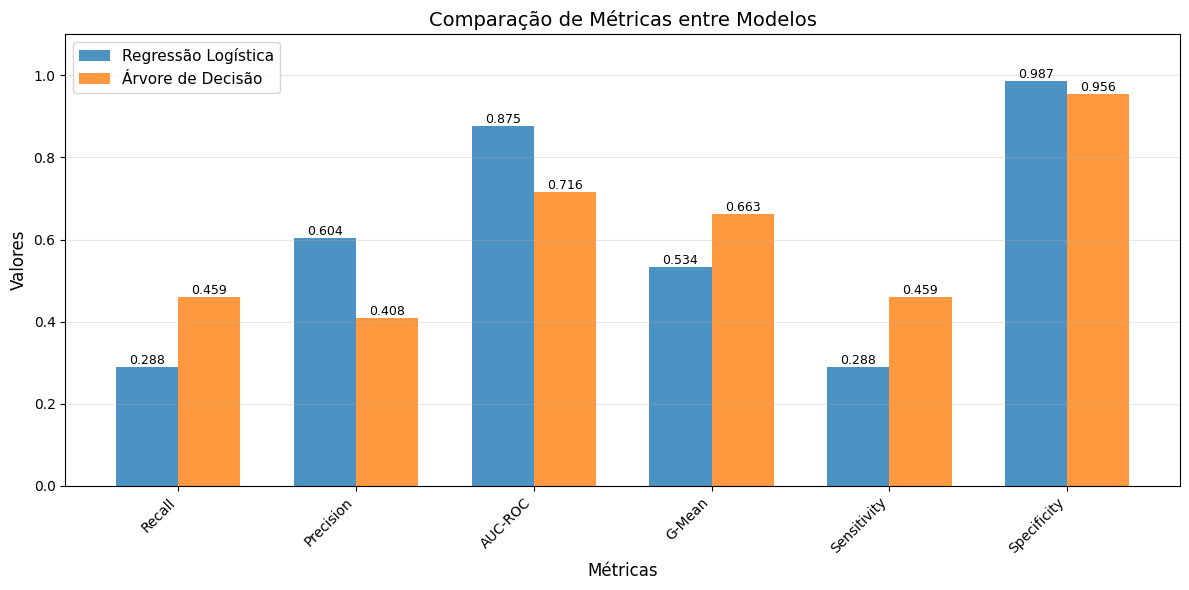

In [17]:
# Visualizar comparação de métricas em gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(resumo_metricas))
width = 0.35

bars1 = ax.bar(x - width/2, resumo_metricas['Regressão Logística'], width, 
               label='Regressão Logística', alpha=0.8)
bars2 = ax.bar(x + width/2, resumo_metricas['Árvore de Decisão'], width, 
               label='Árvore de Decisão', alpha=0.8)

ax.set_xlabel('Métricas', fontsize=12)
ax.set_ylabel('Valores', fontsize=12)
ax.set_title('Comparação de Métricas entre Modelos', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(resumo_metricas['Métrica'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Interpretabilidade dos Modelos

In [18]:
import shap
from sklearn.tree import plot_tree

# Obter os nomes das features diretamente do preprocessor
feature_names = pipeline_dt.named_steps['preprocessor'].get_feature_names_out().tolist()

print(f"Total de features após transformação: {len(feature_names)}")
print("Features:", feature_names)

Total de features após transformação: 19
Features: ['num__LnguaPortuguesaeLiteraturaI90H', 'num__MatemticaI120H', 'num__idade', 'cat__descricao_responsavel_escolaridade_Ensino fundamental completo', 'cat__descricao_responsavel_escolaridade_Ensino fundamental incompleto', 'cat__descricao_responsavel_escolaridade_Ensino médio completo', 'cat__descricao_responsavel_escolaridade_Ensino médio incompleto', 'cat__descricao_responsavel_escolaridade_Ensino superior completo', 'cat__descricao_responsavel_escolaridade_Ensino superior incompleto', 'cat__descricao_responsavel_escolaridade_Não conhece', 'cat__descricao_responsavel_escolaridade_Não estudou', 'cat__descricao_responsavel_escolaridade_Pós graduação completo', 'cat__descricao_responsavel_escolaridade_Pós graduação incompleto', 'cat__descricao_raca_Branca', 'cat__descricao_raca_Indígena', 'cat__descricao_raca_Não declarado', 'cat__descricao_raca_Parda', 'cat__descricao_raca_Preta', 'cat__pessoa_fisica__sexo_M']


### Regressão Logística: Pesos dos Atributos

Pesos dos Atributos (Regressão Logística):
                                              Feature      Peso
1                                 num__MatemticaI120H -4.012320
2                                          num__idade  2.831932
0                 num__LnguaPortuguesaeLiteraturaI90H -2.602058
12  cat__descricao_responsavel_escolaridade_Pós gr... -0.943266
14                       cat__descricao_raca_Indígena -0.759364
17                          cat__descricao_raca_Preta -0.550842
16                          cat__descricao_raca_Parda -0.493654
5   cat__descricao_responsavel_escolaridade_Ensino... -0.375007
3   cat__descricao_responsavel_escolaridade_Ensino... -0.283765
8   cat__descricao_responsavel_escolaridade_Ensino... -0.144921
10  cat__descricao_responsavel_escolaridade_Não es... -0.140858
13                         cat__descricao_raca_Branca -0.116106
11  cat__descricao_responsavel_escolaridade_Pós gr...  0.103648
9   cat__descricao_responsavel_escolaridade_Não co... -0.0919

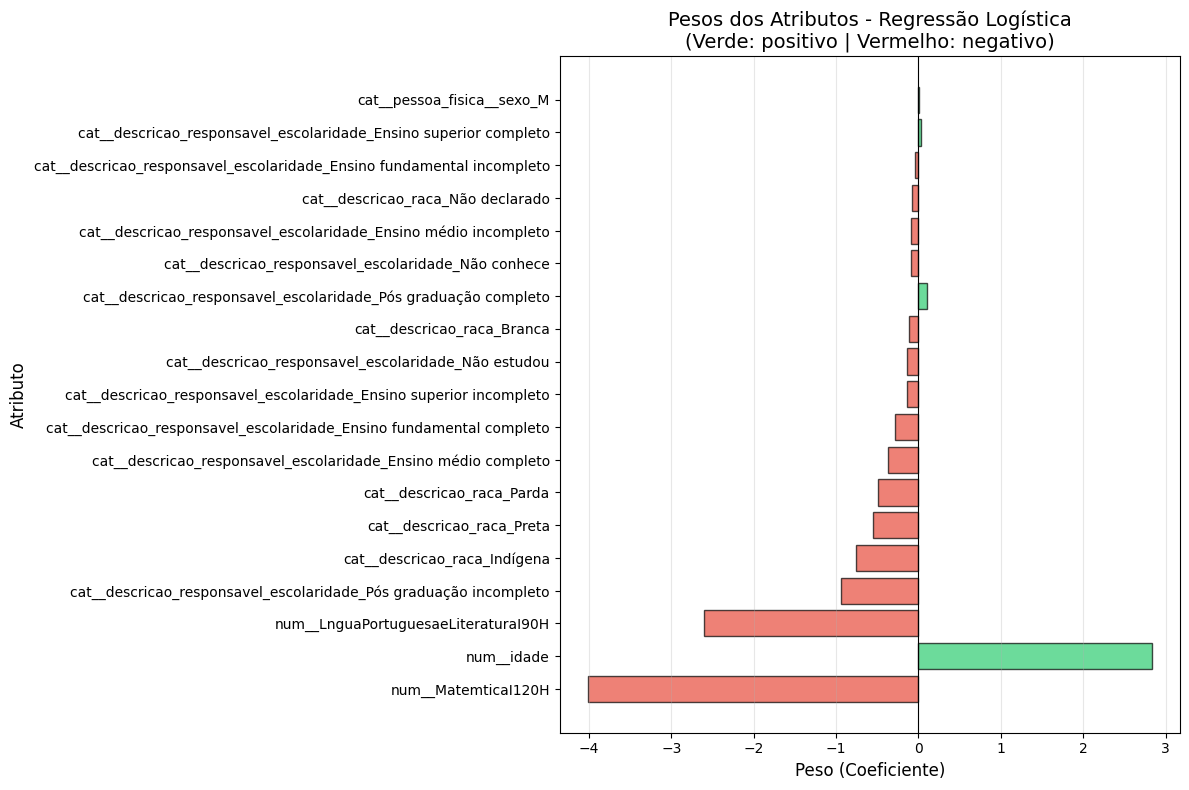

In [19]:
# Extrair os coeficientes (pesos) da regressão logística
coeficientes = pipeline_lr.named_steps['classifier'].coef_[0]

# Criar DataFrame com pesos e nomes das features
pesos_df = pd.DataFrame({
    'Feature': feature_names,
    'Peso': coeficientes
})

# Ordenar por valor absoluto do peso (do maior para o menor)
pesos_df['Peso_Abs'] = pesos_df['Peso'].abs()
pesos_df = pesos_df.sort_values('Peso_Abs', ascending=False).drop('Peso_Abs', axis=1)

print("Pesos dos Atributos (Regressão Logística):")
print(pesos_df)

# Plotar os pesos em gráfico de barras
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in pesos_df['Peso']]
ax.barh(pesos_df['Feature'], pesos_df['Peso'], color=colors, alpha=0.7, edgecolor='black')

ax.set_xlabel('Peso (Coeficiente)', fontsize=12)
ax.set_ylabel('Atributo', fontsize=12)
ax.set_title('Pesos dos Atributos - Regressão Logística\n(Verde: positivo | Vermelho: negativo)', fontsize=14)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Árvore de Decisão: Visualização da Árvore

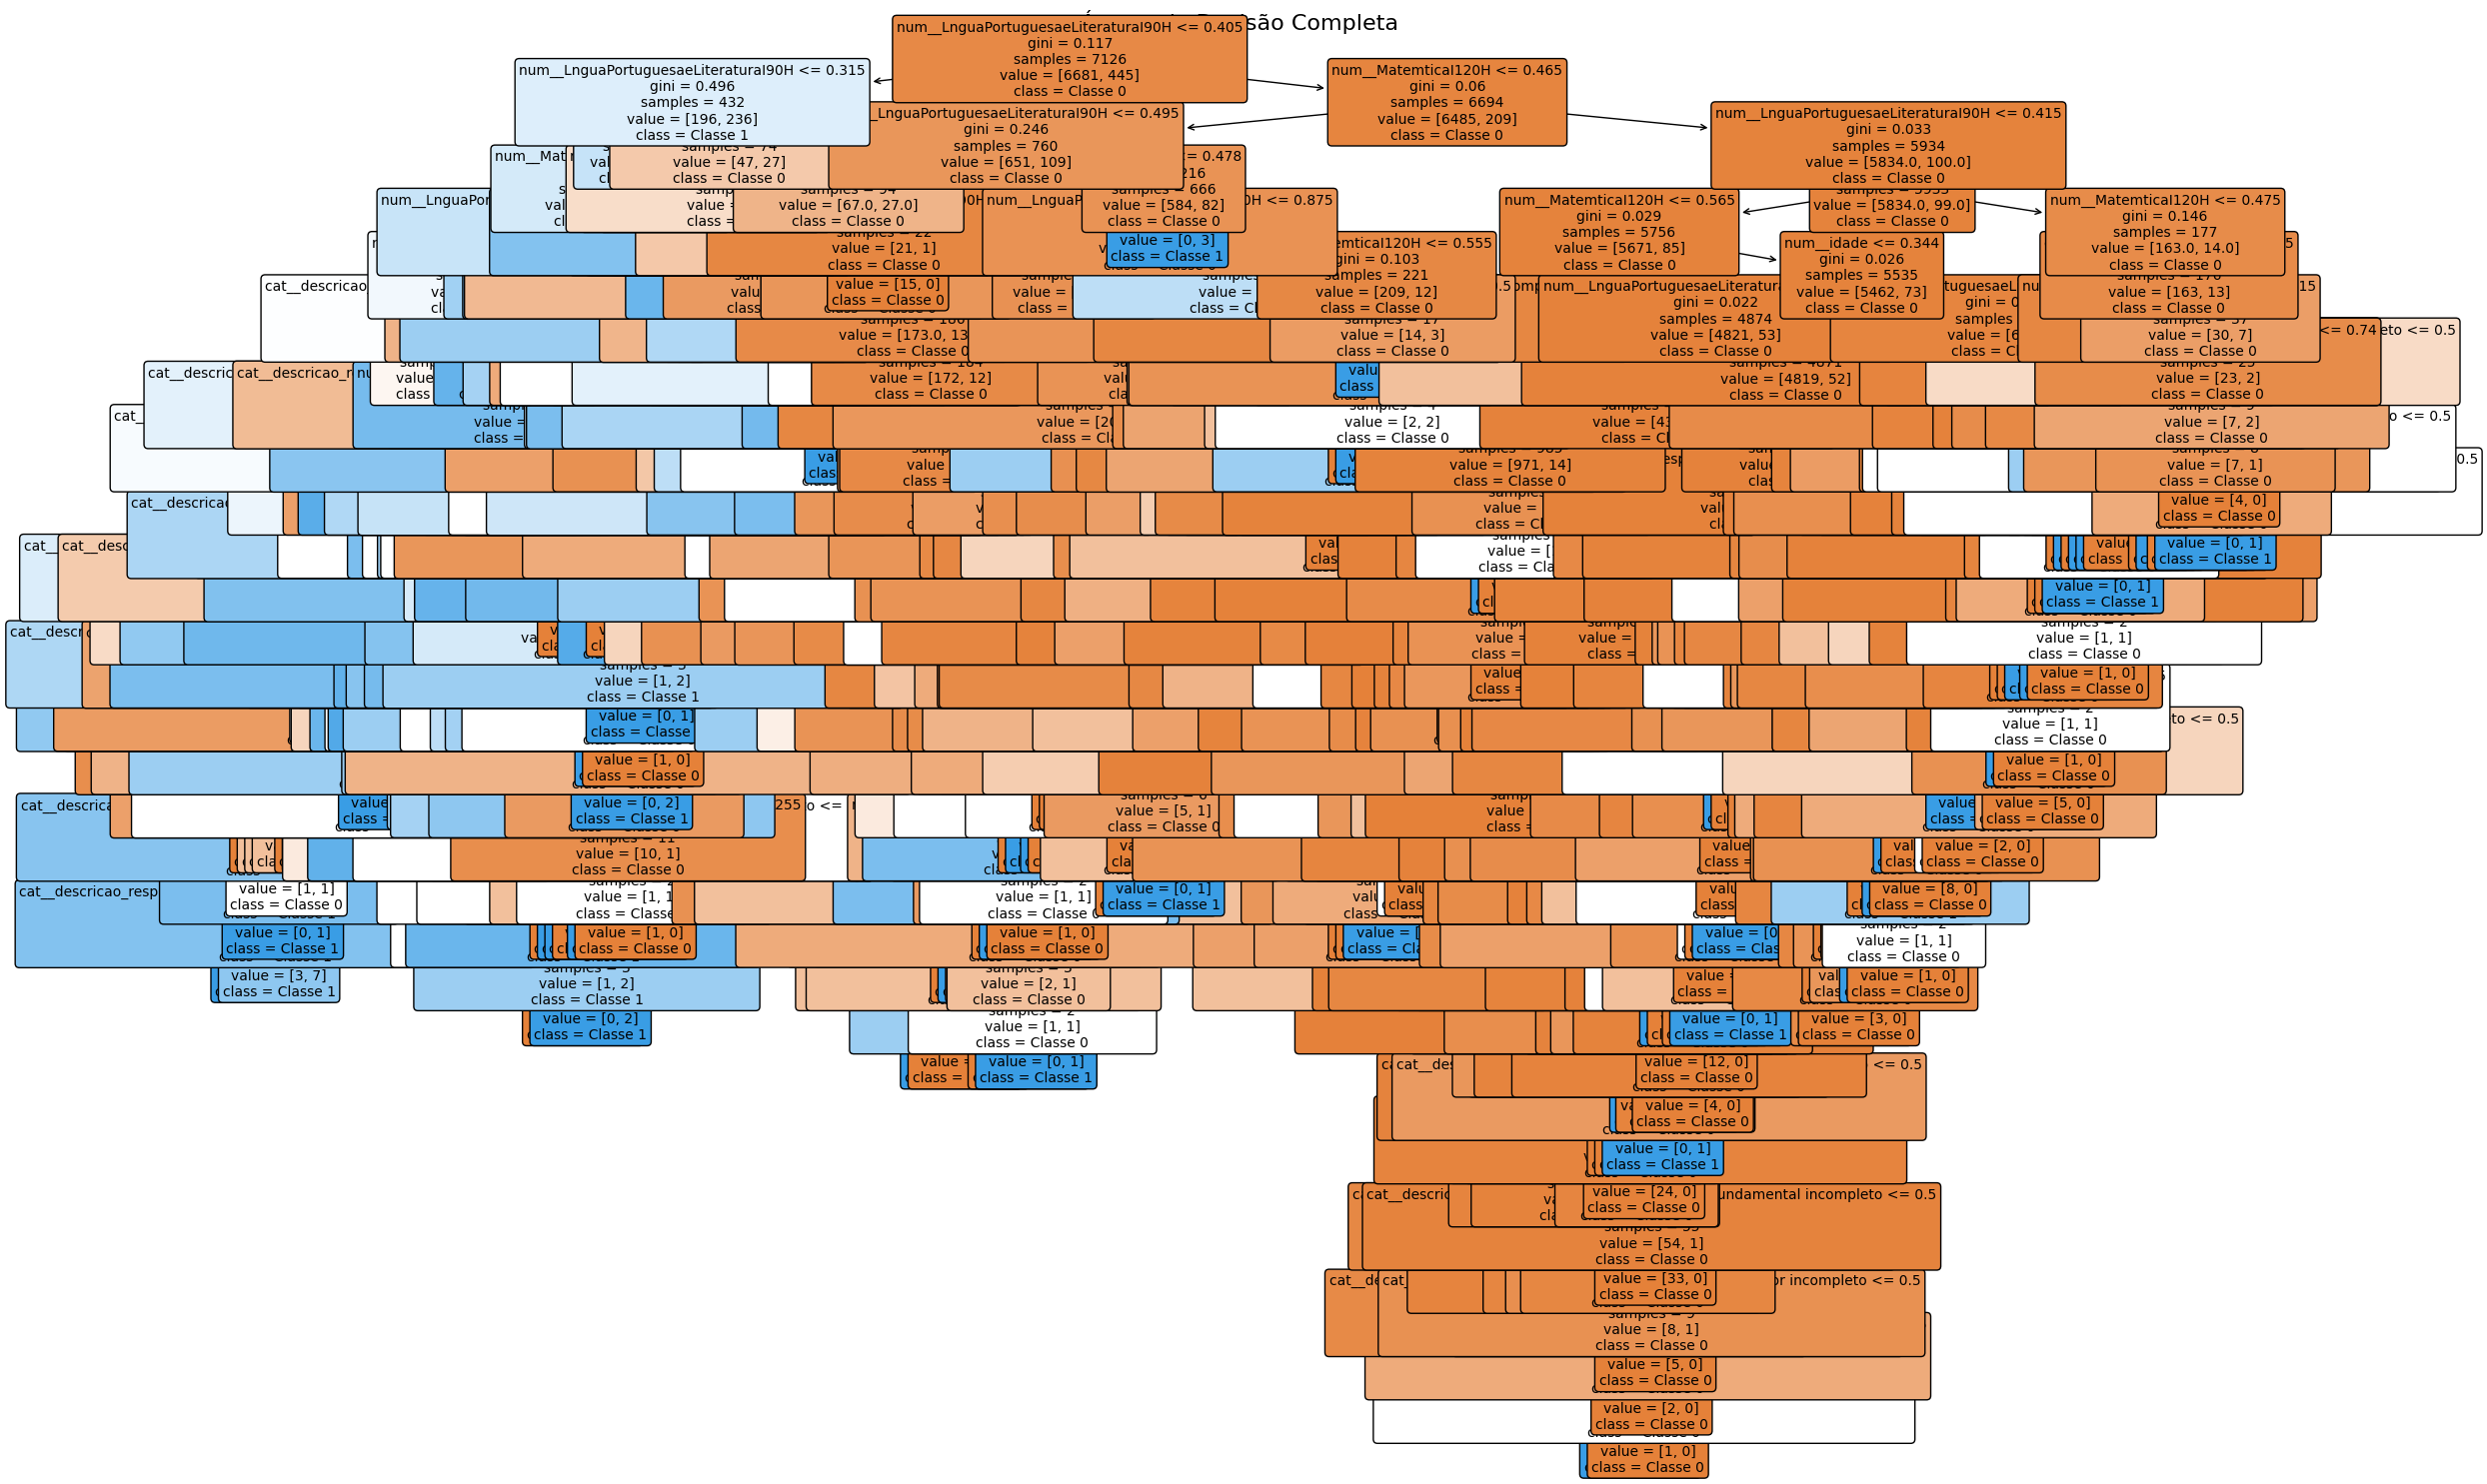

In [20]:
# Visualizar a árvore de decisão
plt.figure(figsize=(25, 15))
plot_tree(pipeline_dt.named_steps['classifier'], 
          feature_names=feature_names,
          class_names=['Classe 0', 'Classe 1'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árvore de Decisão Completa', fontsize=16)
plt.tight_layout()
plt.show()

### Árvore de Decisão: Feature Importance

Feature Importance (Árvore de Decisão):
                                              Feature  Importance
0                 num__LnguaPortuguesaeLiteraturaI90H    0.468537
1                                 num__MatemticaI120H    0.206761
2                                          num__idade    0.076949
18                         cat__pessoa_fisica__sexo_M    0.043134
4   cat__descricao_responsavel_escolaridade_Ensino...    0.028813
5   cat__descricao_responsavel_escolaridade_Ensino...    0.028659
3   cat__descricao_responsavel_escolaridade_Ensino...    0.022167
13                         cat__descricao_raca_Branca    0.022121
16                          cat__descricao_raca_Parda    0.021877
7   cat__descricao_responsavel_escolaridade_Ensino...    0.016884
10  cat__descricao_responsavel_escolaridade_Não es...    0.015976
6   cat__descricao_responsavel_escolaridade_Ensino...    0.012908
8   cat__descricao_responsavel_escolaridade_Ensino...    0.012189
11  cat__descricao_responsavel_escol

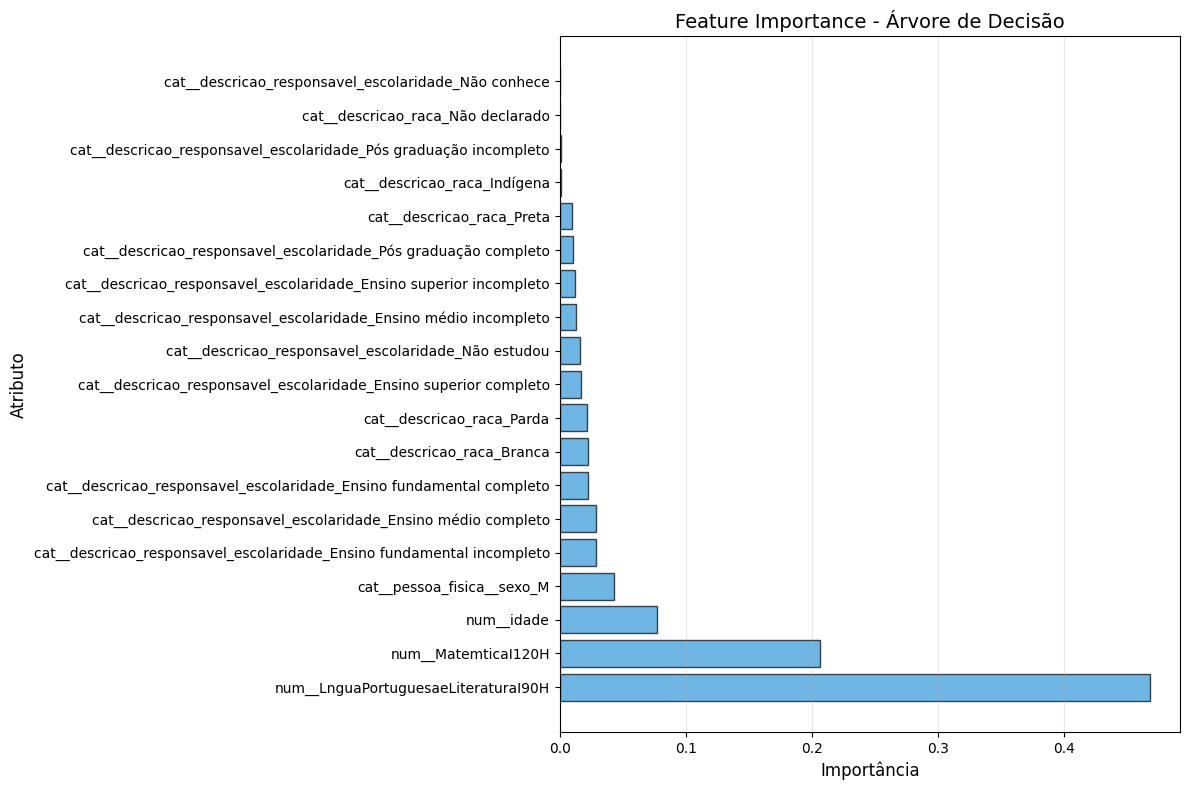

In [21]:
# Extrair feature importance da árvore de decisão
importances = pipeline_dt.named_steps['classifier'].feature_importances_

# Criar DataFrame com importâncias e nomes das features
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ordenar por importância (do maior para o menor)
importance_df = importance_df.sort_values('Importance', ascending=False)

print("Feature Importance (Árvore de Decisão):")
print(importance_df)

# Plotar feature importance
fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(importance_df['Feature'], importance_df['Importance'], 
        color='#3498db', alpha=0.7, edgecolor='black')

ax.set_xlabel('Importância', fontsize=12)
ax.set_ylabel('Atributo', fontsize=12)
ax.set_title('Feature Importance - Árvore de Decisão', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### SHAP Values: Análise de Importância

In [22]:
# Preparar dados para SHAP (transformar X_test)
X_test_transformed = pipeline_dt.named_steps['preprocessor'].transform(X_test)

# Converter para array denso se for sparse
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

print(f"Shape de X_test_transformed: {X_test_transformed.shape}")
print(f"Número de features: {len(feature_names)}")

# Criar explainer SHAP para a árvore de decisão
tree_model = pipeline_dt.named_steps['classifier']
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_test_transformed)

# Verificar a estrutura dos shap_values
print(f"\nTipo de shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"É uma lista com {len(shap_values)} elementos")
    print(f"Shape de shap_values[0]: {shap_values[0].shape}")
    print(f"Shape de shap_values[1]: {shap_values[1].shape}")
    shap_values_class0 = shap_values[0]
    shap_values_class1 = shap_values[1]
else:
    # Para versões mais recentes do SHAP que retornam array 3D
    print(f"Shape de shap_values: {shap_values.shape}")
    if len(shap_values.shape) == 3:
        shap_values_class0 = shap_values[:, :, 0]
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
        shap_values_class0 = -shap_values

print("\nSHAP values extraídos com sucesso!")

Shape de X_test_transformed: (1782, 19)
Número de features: 19

Tipo de shap_values: <class 'numpy.ndarray'>
Shape de shap_values: (1782, 19, 2)

SHAP values extraídos com sucesso!


#### SHAP Beeswarm Plot - Todos os dados (classes 0 e 1 juntas)

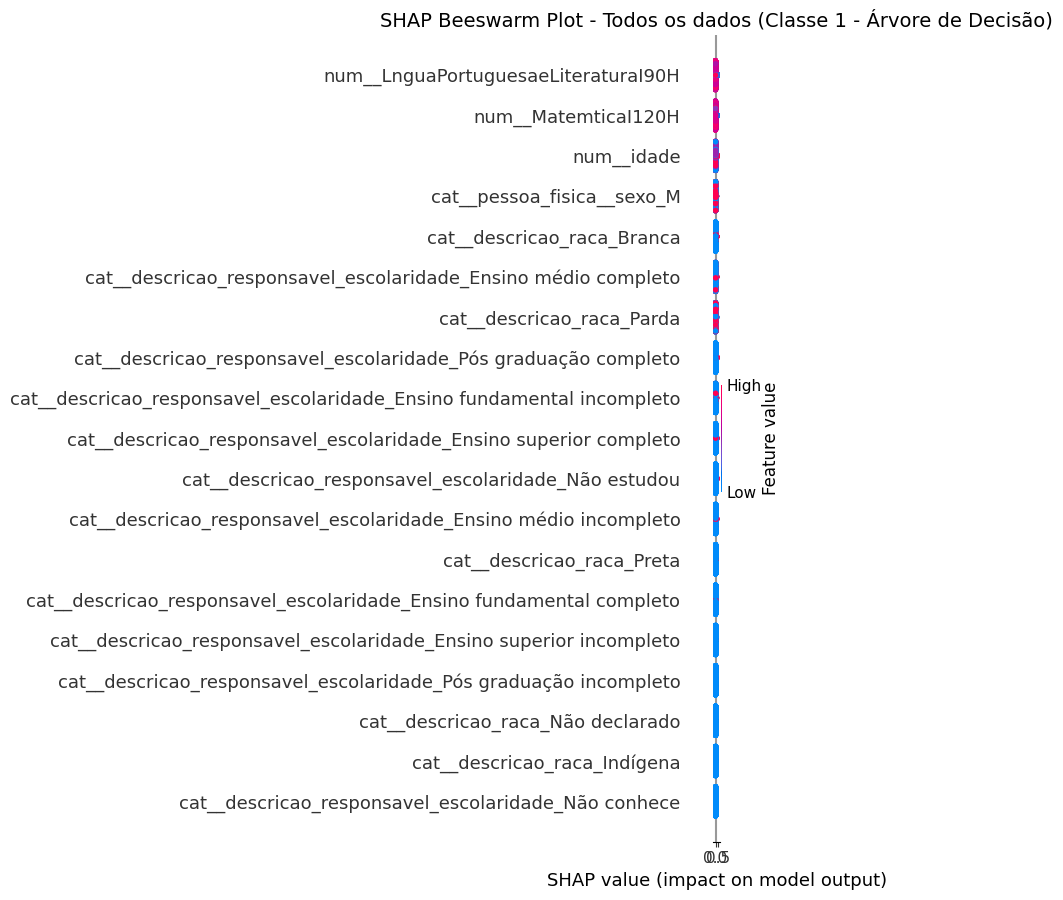

In [23]:
# SHAP Beeswarm Plot (todos os dados)
# Observação: em classificação binária, é comum visualizar os SHAP values da classe 1 para todas as amostras.
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_class1,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="dot",
    show=False
)
plt.title('SHAP Beeswarm Plot - Todos os dados (Classe 1 - Árvore de Decisão)', fontsize=14)
plt.tight_layout()
plt.show()

#### SHAP Bar Plot - Somente amostras com y_test = 1

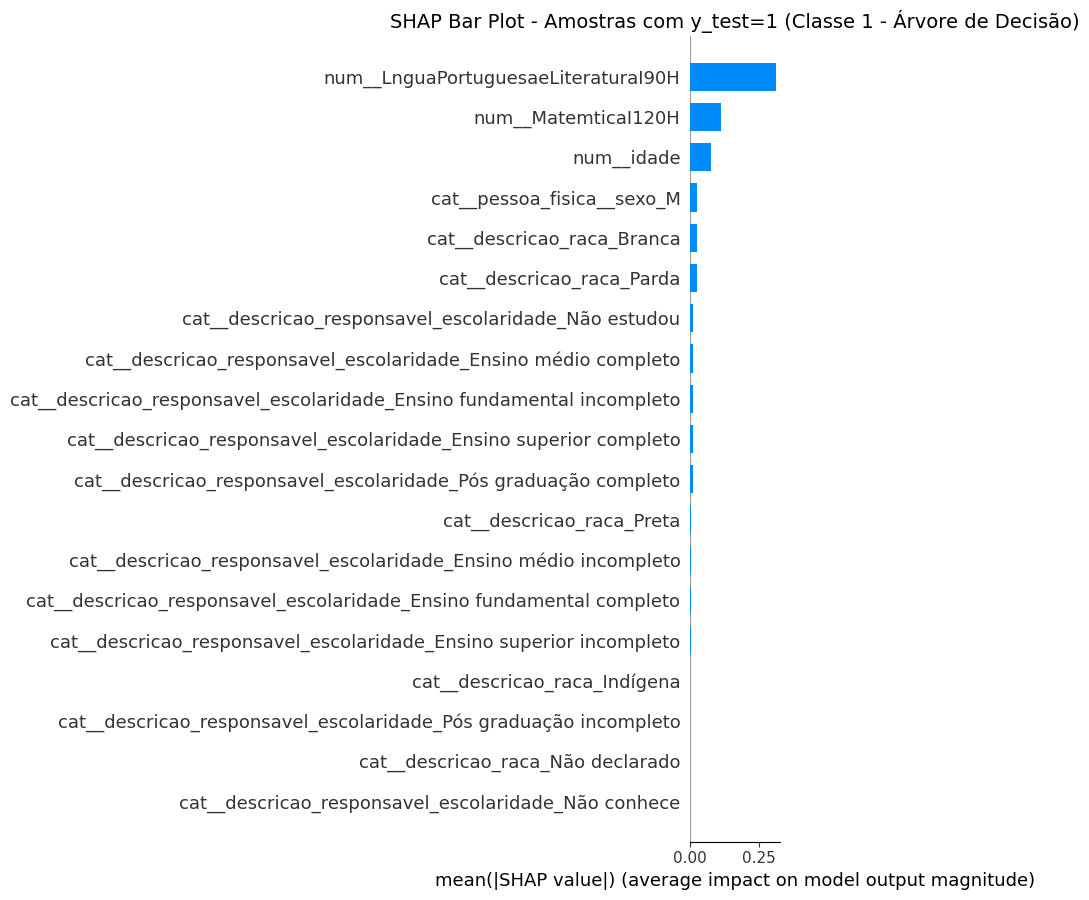

In [24]:
# SHAP Bar Plot para amostras cuja classe verdadeira é 1
mask_1 = (y_test.values == 1)

if mask_1.sum() == 0:
    print("Não há amostras da classe 1 no conjunto de teste.")
else:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_class1[mask_1],
        X_test_transformed[mask_1],
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title('SHAP Bar Plot - Amostras com y_test=1 (Classe 1 - Árvore de Decisão)', fontsize=14)
    plt.tight_layout()
    plt.show()

#### SHAP Bar Plot - Somente amostras com y_test = 0

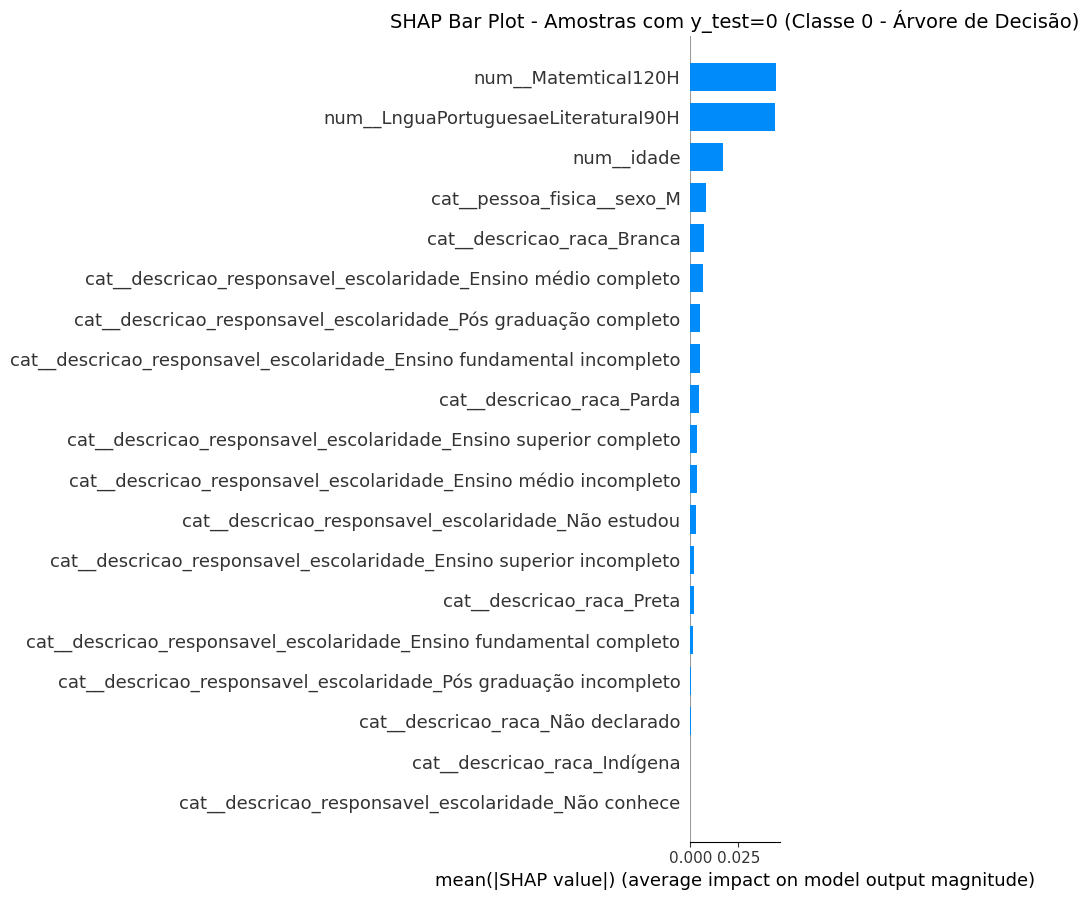

In [25]:
# SHAP Bar Plot para amostras cuja classe verdadeira é 0
mask_0 = (y_test.values == 0)

if mask_0.sum() == 0:
    print("Não há amostras da classe 0 no conjunto de teste.")
else:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_class0[mask_0],
        X_test_transformed[mask_0],
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title('SHAP Bar Plot - Amostras com y_test=0 (Classe 0 - Árvore de Decisão)', fontsize=14)
    plt.tight_layout()
    plt.show()

In [26]:
import pickle
import os

# Salvar o modelo da árvore em formato pkl
modelo_path = 'modelo_arvore_decisao.pkl'

with open(modelo_path, 'wb') as f:
    pickle.dump(pipeline_dt, f)

print(f"Modelo salvo com sucesso em: {modelo_path}")
print(f"Tamanho do arquivo: {os.path.getsize(modelo_path) / 1024:.2f} KB")

Modelo salvo com sucesso em: modelo_arvore_decisao.pkl
Tamanho do arquivo: 103.07 KB


In [27]:
# Carregar o modelo salvo em uma nova variável
modelo_carregado = pickle.load(open(modelo_path, 'rb'))

print("Modelo carregado com sucesso!")
print(f"Tipo do modelo: {type(modelo_carregado)}")
print(f"\nPipeline carregado contém:")
print(f"  - Preprocessador: {modelo_carregado.named_steps['preprocessor']}")
print(f"  - Classificador: {modelo_carregado.named_steps['classifier']}")

Modelo carregado com sucesso!
Tipo do modelo: <class 'sklearn.pipeline.Pipeline'>

Pipeline carregado contém:
  - Preprocessador: ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', MinMaxScaler())]),
                                 ['LnguaPortuguesaeLiteraturaI90H',
                                  'MatemticaI120H', 'idade']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False))]),
                                 ['descricao_responsa

In [29]:
# Explorar as categorias reais do dataset original
print("Categorias únicas em 'descricao_responsavel_escolaridade':")
print(df_sel['descricao_responsavel_escolaridade'].unique())
print(f"\nTotal de categorias: {df_sel['descricao_responsavel_escolaridade'].nunique()}")

print("\nCategorias únicas em 'descricao_raca':")
print(df_sel['descricao_raca'].unique())
print(f"\nTotal de categorias: {df_sel['descricao_raca'].nunique()}")

print("\nCategorias únicas em 'pessoa_fisica__sexo':")
print(df_sel['pessoa_fisica__sexo'].unique())
print(f"\nTotal de categorias: {df_sel['pessoa_fisica__sexo'].nunique()}")

Categorias únicas em 'descricao_responsavel_escolaridade':
['Ensino fundamental incompleto' 'Ensino médio completo' 'Alfabetizado'
 'Pós graduação completo' 'Ensino superior completo'
 'Ensino médio incompleto' 'Ensino fundamental completo' 'Não estudou'
 'Ensino superior incompleto' 'Pós graduação incompleto' 'Não conhece']

Total de categorias: 11

Categorias únicas em 'descricao_raca':
['Branca' 'Parda' 'Preta' 'Amarela' 'Não declarado' 'Indígena']

Total de categorias: 6

Categorias únicas em 'pessoa_fisica__sexo':
['F' 'M']

Total de categorias: 2


Categorias para geração de dados fake:
  Escolaridade: ['Ensino fundamental incompleto', 'Ensino médio completo', 'Alfabetizado', 'Pós graduação completo', 'Ensino superior completo', 'Ensino médio incompleto', 'Ensino fundamental completo', 'Não estudou', 'Ensino superior incompleto', 'Pós graduação incompleto', 'Não conhece']
  Raça: ['Branca', 'Parda', 'Preta', 'Amarela', 'Não declarado', 'Indígena']
  Sexo: ['F', 'M']

Dados Fake Gerados:
   LnguaPortuguesaeLiteraturaI90H  MatemticaI120H  \
0                              51              20   
1                              92              82   
2                              14              86   
3                              71              74   
4                              60              74   

  descricao_responsavel_escolaridade  idade descricao_raca pessoa_fisica__sexo  
0                        Não estudou     20       Indígena                   F  
1           Ensino superior completo     39       Indígena              

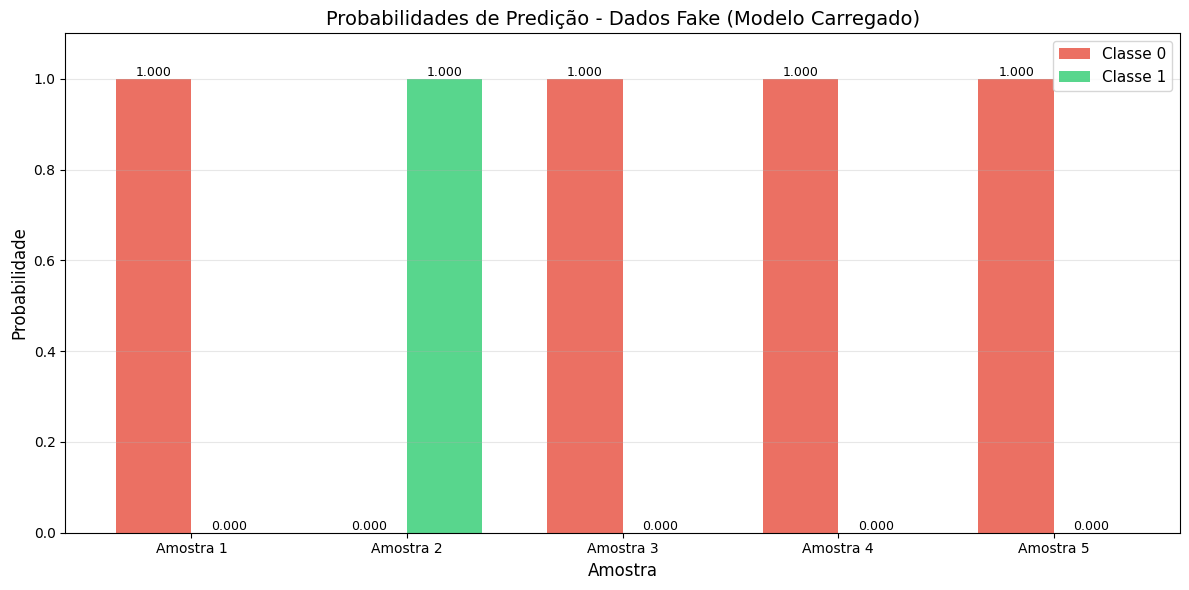

In [30]:
# Gerar dados fake com as mesmas features e categorias reais do modelo original
np.random.seed(42)

# Obter as categorias reais do dataset de treino
categorias_escolaridade = df_sel['descricao_responsavel_escolaridade'].unique().tolist()
categorias_raca = df_sel['descricao_raca'].unique().tolist()
categorias_sexo = df_sel['pessoa_fisica__sexo'].unique().tolist()

print(f"Categorias para geração de dados fake:")
print(f"  Escolaridade: {categorias_escolaridade}")
print(f"  Raça: {categorias_raca}")
print(f"  Sexo: {categorias_sexo}")

# Criar dados fake com as categorias corretas
dados_fake = pd.DataFrame({
    'LnguaPortuguesaeLiteraturaI90H': np.random.randint(0, 100, 5),
    'MatemticaI120H': np.random.randint(0, 100, 5),
    'descricao_responsavel_escolaridade': np.random.choice(categorias_escolaridade, 5),
    'idade': np.random.randint(18, 65, 5),
    'descricao_raca': np.random.choice(categorias_raca, 5),
    'pessoa_fisica__sexo': np.random.choice(categorias_sexo, 5)
})

print("\n" + "="*80)
print("Dados Fake Gerados:")
print("="*80)
print(dados_fake)
print("\n" + "="*80)

# Fazer predições com o modelo carregado
predicoes = modelo_carregado.predict(dados_fake)
probabilidades = modelo_carregado.predict_proba(dados_fake)

print("\nResultados das Predições:")
print("="*80)

resultado_df = pd.DataFrame({
    'Amostra': range(1, len(dados_fake) + 1),
    'Predição (Classe)': predicoes,
    'Probabilidade Classe 0': probabilidades[:, 0],
    'Probabilidade Classe 1': probabilidades[:, 1],
    'Confiança': probabilidades.max(axis=1)
})

print(resultado_df.to_string(index=False))

# Visualizar os resultados
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(resultado_df))
width = 0.35

bars1 = ax.bar(x_pos - width/2, resultado_df['Probabilidade Classe 0'], width, 
               label='Classe 0', alpha=0.8, color='#e74c3c')
bars2 = ax.bar(x_pos + width/2, resultado_df['Probabilidade Classe 1'], width, 
               label='Classe 1', alpha=0.8, color='#2ecc71')

ax.set_xlabel('Amostra', fontsize=12)
ax.set_ylabel('Probabilidade', fontsize=12)
ax.set_title('Probabilidades de Predição - Dados Fake (Modelo Carregado)', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Amostra {i}' for i in range(1, len(dados_fake) + 1)])
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()